In [1]:
# Import libraries
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Make results more reproducible
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# Load the dataset (keep data.csv in the same folder as this notebook)
df = pd.read_csv('data.csv')

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Prepare features and target
# id is only an identifier, and Unnamed: 32 is an empty column.
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis'].map({'B': 0, 'M': 1})

print('Features:', X.shape[1])
print('Target values:', sorted(y.unique()))

Features: 30
Target values: [np.int64(0), np.int64(1)]


In [4]:
# Split the data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale using training-data statistics only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training rows:', X_train_scaled.shape[0])
print('Testing rows:', X_test_scaled.shape[0])

Training rows: 455
Testing rows: 114


In [5]:
# Build the exact required ANN architecture
model = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train for 30 epochs; 20% of the training set is used for validation
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5824 - loss: 0.6834 - val_accuracy: 0.7802 - val_loss: 0.5693
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7473 - loss: 0.5683 - val_accuracy: 0.8132 - val_loss: 0.4816
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8159 - loss: 0.4880 - val_accuracy: 0.8791 - val_loss: 0.4163
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8819 - loss: 0.4249 - val_accuracy: 0.8901 - val_loss: 0.3628
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9121 - loss: 0.3704 - val_accuracy: 0.9231 - val_loss: 0.3187
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9423 - loss: 0.3225 - val_accuracy: 0.9231 - val_loss: 0.2822
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9533 - loss: 0.2812 - val_accuracy: 0.9231 - val_loss: 0.2513
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9560 - loss: 0.2472 - val_accuracy: 0.9341 - val_loss

In [7]:
# Evaluate on data the model did not see during training
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Final test accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)')
print(f'Final test loss: {test_loss:.4f}')

Final test accuracy: 0.9825 (98.25%)
Final test loss: 0.0919


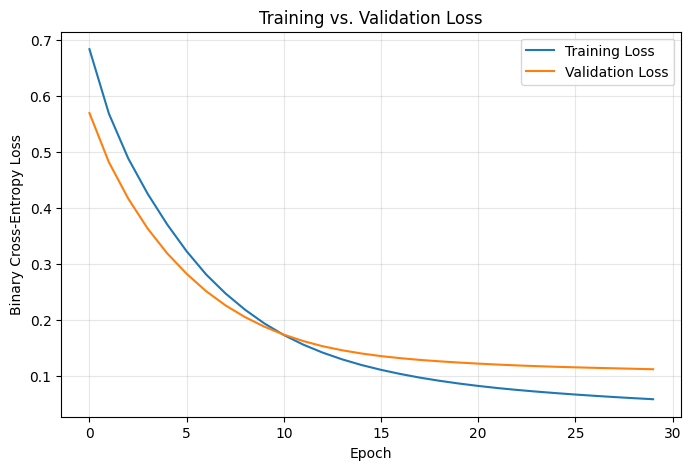

In [8]:
# Plot training loss against validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Forward propagation and backpropagation

During forward propagation, the input values move through the network's layers to produce a prediction, and the loss function measures how far that prediction is from the correct diagnosis. During backpropagation, the model sends the error backward through the network, calculates how each weight contributed to it, and the Adam optimizer updates those weights so the next epoch can make better predictions.